In [1]:
import pandas as pd

### Loading Datasets

In [2]:
customers_dataset_df = pd.read_csv("../data/olist_customers_dataset.csv")
orders_dataset_df = pd.read_csv("../data/olist_orders_dataset.csv")
order_items_dataset_df = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments_dataset_df = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews_dataset_df = pd.read_csv("../data/olist_order_reviews_dataset.csv")
sellers_dataset_df = pd.read_csv("../data/olist_sellers_dataset.csv")
products_dataset_df = pd.read_csv("../data/olist_products_dataset.csv")
geolocation_dataset_df = pd.read_csv("../data/olist_geolocation_dataset.csv")
products_name_translation_df = pd.read_csv("../data/product_category_name_translation.csv")


### Merging DataSets with Relationships

In [4]:
# orders_dataset_df
# order_items_dataset_df.describe()

main_df = orders_dataset_df.merge(order_items_dataset_df, on='order_id', how='left')
# main_df.describe(include='str')
main_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value'],
      dtype='str')

In [5]:
products_dataset_df.columns
# main_df.info()
main_df = main_df.merge(products_dataset_df, on='product_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  str    
 10  seller_id                      112650 non-null  str    
 11  shipping_limit_date            112650 non-null  str    
 12  price                          112650 non

In [6]:
sellers_dataset_df.info()
sellers_dataset_df['seller_id'].duplicated().sum()
sellers_dataset_df['seller_id'].isnull().sum()
main_df = main_df.merge(sellers_dataset_df, on='seller_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_car

In [7]:
order_payments_dataset_df.info()
order_payments_dataset_df['order_id'].duplicated().sum()

payment_types = [
    'credit_card',
    'boleto',
    'voucher',
    'debit_card',
    'not_defined'
]

for payment in payment_types:
    order_payments_dataset_df[f'used_{payment}'] = (order_payments_dataset_df['payment_type'] == payment).astype(int)
    
payment_summary = order_payments_dataset_df.groupby('order_id').agg(payment_type_count=('payment_type', 'count'), 
                                                      used_credit_card=('used_credit_card', 'max'), 
                                                      used_boleto=('used_boleto', 'max'), 
                                                      used_voucher=('used_voucher', 'max'), 
                                                      used_debit_card=('used_debit_card', 'max'), 
                                                      used_not_defined=('used_not_defined', 'max'),
                                                      total_payment_value=('payment_value', 'sum')).reset_index()

payment_summary.shape

main_df = main_df.merge(payment_summary, on='order_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_ap

In [9]:
customers_dataset_df.info()
customers_dataset_df['customer_id'].unique()
customers_dataset_df.duplicated().sum()

customers_dataset_df.isnull().sum()
main_df = main_df.merge(customers_dataset_df, on='customer_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved

In [17]:
products_name_translation_df.info()
products_name_translation_df['product_category_name'].duplicated().sum()

main_df = main_df.merge(products_name_translation_df, on='product_category_name', how='left')
main_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  

### Analyzing missing values and duplicates in Main dataset


In [38]:
missing_values = pd.DataFrame(main_df.isnull().sum())
missing_values.rename(columns = {0: "Missing Values Count"}, inplace = True)

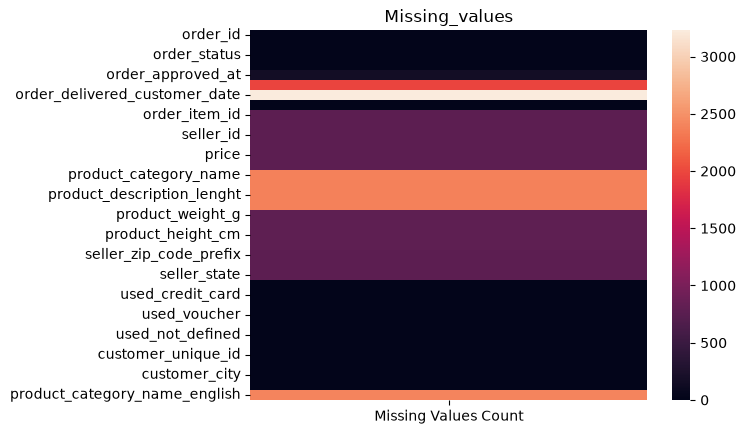

In [55]:
# Visulaizing Missing values
import matplotlib.pyplot as plt
import seaborn as sns


sns.heatmap(data=missing_values)
plt.title("Missing_values")
plt.show()

In [41]:
main_df.duplicated().sum()

np.int64(0)

In [51]:
# Dimensions
print("Main_dataset : \n(Rows, columns)\n", main_df.shape)

Main_dataset : 
(Rows, columns)
 (113425, 37)


In [ ]:
# Descriptive Stats for numerical features
main_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,shipping_limit_date,product_category_name,seller_city,seller_state,customer_unique_id,customer_city,customer_state,product_category_name_english
count,113425,113425,113425,113425,113264,111457,110196,113425,112650,112650,112650,111047,112650,112650,113425,113425,113425,111023
unique,99441,99441,8,98875,90733,81018,95664,459,32951,3095,93318,73,611,23,96096,4119,27,71
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2018-02-24 03:20:27,2018-05-09 15:48:00,2017-07-31 18:03:02,2017-12-20 00:00:00,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,cama_mesa_banho,sao paulo,SP,c8460e4251689ba205045f3ea17884a1,sao paulo,SP,bed_bath_table
freq,21,21,110197,21,23,48,21,611,527,2033,21,11115,27983,80342,24,17946,47820,11115


In [45]:
# Descriptive Stats for categorical features
main_df.describe(include='str')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,shipping_limit_date,product_category_name,seller_city,seller_state,customer_unique_id,customer_city,customer_state,product_category_name_english
count,113425,113425,113425,113425,113264,111457,110196,113425,112650,112650,112650,111047,112650,112650,113425,113425,113425,111023
unique,99441,99441,8,98875,90733,81018,95664,459,32951,3095,93318,73,611,23,96096,4119,27,71
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2018-02-24 03:20:27,2018-05-09 15:48:00,2017-07-31 18:03:02,2017-12-20 00:00:00,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,cama_mesa_banho,sao paulo,SP,c8460e4251689ba205045f3ea17884a1,sao paulo,SP,bed_bath_table
freq,21,21,110197,21,23,48,21,611,527,2033,21,11115,27983,80342,24,17946,47820,11115


In [56]:
# Creating Dataset 
main_df.to_csv("../data/main_dataset.csv", index=False)